In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report


np.random.seed(42)

## 1. Введение и описание данных

### 1.1. Датасет Iris (классификация)

In [2]:
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

print("Данные Iris:")
print(f"Количество объектов: {X_iris.shape[0]}")
print(f"Количество признаков: {X_iris.shape[1]}")
print(f"Признаки: {feature_names_iris}")
print(f"Классы: {target_names_iris}")

Данные Iris:
Количество объектов: 150
Количество признаков: 4
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы: ['setosa' 'versicolor' 'virginica']


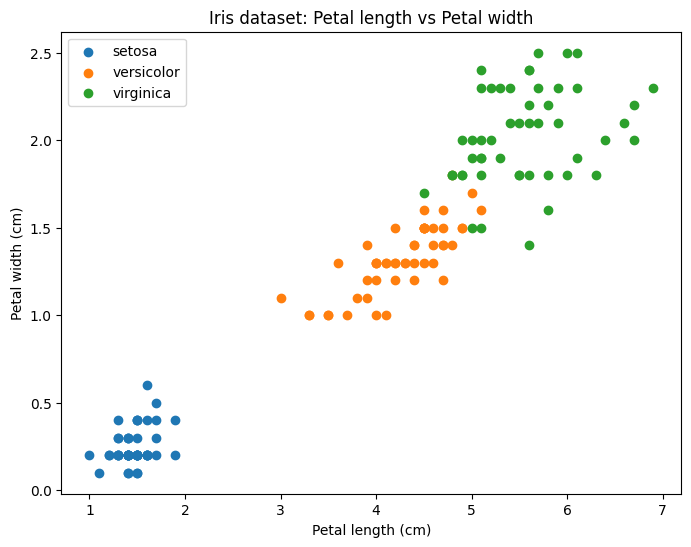

In [3]:
# Визуализация Iris
plt.figure(figsize=(8, 6))
for i, target_name in enumerate(target_names_iris):
    plt.scatter(X_iris[y_iris == i, 2], X_iris[y_iris == i, 3], label=target_name)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Iris dataset: Petal length vs Petal width')
plt.legend()
plt.show()

Классы хорошо разделяются по признакам petal length и petal width, но не линейно.

### 1.2. Датасет Diabetes (регрессия)

In [4]:
diabetes = datasets.load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target
feature_names_diabetes = diabetes.feature_names

print("Данные Diabetes:")
print(f"Количество объектов: {X_diabetes.shape[0]}")
print(f"Количество признаков: {X_diabetes.shape[1]}")
print(f"Признаки: {feature_names_diabetes}")
print(f"Целевая переменная: количественный показатель прогрессирования болезни через год")

Данные Diabetes:
Количество объектов: 442
Количество признаков: 10
Признаки: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Целевая переменная: количественный показатель прогрессирования болезни через год


In [5]:
# Масштаб данных
print("Масштаб признаков (min, max):")
for i, name in enumerate(feature_names_diabetes):
    print(f"{name}: [{X_diabetes[:, i].min():.2f}, {X_diabetes[:, i].max():.2f}]")
print(f"\nЦелевая переменная: [{y_diabetes.min():.2f}, {y_diabetes.max():.2f}]")

Масштаб признаков (min, max):
age: [-0.11, 0.11]
sex: [-0.04, 0.05]
bmi: [-0.09, 0.17]
bp: [-0.11, 0.13]
s1: [-0.13, 0.15]
s2: [-0.12, 0.20]
s3: [-0.10, 0.18]
s4: [-0.08, 0.19]
s5: [-0.13, 0.13]
s6: [-0.14, 0.14]

Целевая переменная: [25.00, 346.00]


Признаки уже отмасштабированы, целевая переменная имеет широкий диапазон.

## 2. Разделение данных

In [7]:
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.3, random_state=42
)

print("Разделение выполнено:")
print(f"Iris: train {X_iris_train.shape[0]}, test {X_iris_test.shape[0]}")
print(f"Diabetes: train {X_diabetes_train.shape[0]}, test {X_diabetes_test.shape[0]}")

Разделение выполнено:
Iris: train 105, test 45
Diabetes: train 309, test 133


## 3. Базовые линейные модели (baseline)

### 3.1. Логистическая регрессия для Iris

In [9]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_iris_train, y_iris_train)

train_acc = log_reg.score(X_iris_train, y_iris_train)
test_acc = log_reg.score(X_iris_test, y_iris_test)

print("Логистическая регрессия (Iris):")
print(f"Точность на обучении: {train_acc:.3f}")
print(f"Точность на тесте: {test_acc:.3f}")

Логистическая регрессия (Iris):
Точность на обучении: 0.962
Точность на тесте: 1.000


Точность на обучении и тесте близки, признаки переобучения нет.

### 3.2. Линейная регрессия для Diabetes

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_diabetes_train, y_diabetes_train)

train_r2 = lin_reg.score(X_diabetes_train, y_diabetes_train)
test_r2 = lin_reg.score(X_diabetes_test, y_diabetes_test)
train_mse = mean_squared_error(y_diabetes_train, lin_reg.predict(X_diabetes_train))
test_mse = mean_squared_error(y_diabetes_test, lin_reg.predict(X_diabetes_test))

print("Линейная регрессия (Diabetes):")
print(f"R² на обучении: {train_r2:.3f}, MSE: {train_mse:.2f}")
print(f"R² на тесте: {test_r2:.3f}, MSE: {test_mse:.2f}")

Линейная регрессия (Diabetes):
R² на обучении: 0.524, MSE: 2924.05
R² на тесте: 0.477, MSE: 2821.75


Модель объясняет около 50% дисперсии, что может быть недостаточно.

## 4. Решающее дерево для классификации (Iris)

### 4.1. Базовое дерево с разными критериями

In [11]:
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_iris_train, y_iris_train)

tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_entropy.fit(X_iris_train, y_iris_train)

print("Дерево с критерием Gini:")
print(f"Точность на обучении: {tree_gini.score(X_iris_train, y_iris_train):.3f}")
print(f"Точность на тесте: {tree_gini.score(X_iris_test, y_iris_test):.3f}")
print("\nДерево с критерием энтропии:")
print(f"Точность на обучении: {tree_entropy.score(X_iris_train, y_iris_train):.3f}")
print(f"Точность на тесте: {tree_entropy.score(X_iris_test, y_iris_test):.3f}")

Дерево с критерием Gini:
Точность на обучении: 1.000
Точность на тесте: 1.000

Дерево с критерием энтропии:
Точность на обучении: 1.000
Точность на тесте: 0.978


**Вывод:** Оба дерева переобучены (точность на обучении 1.0, на тесте ниже).

### 4.2. Визуализация решений

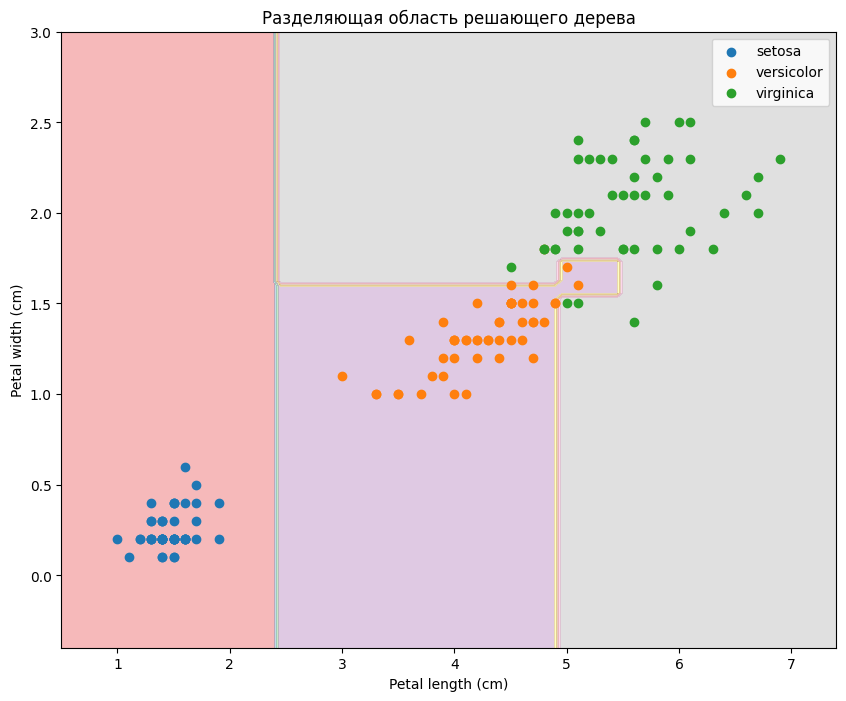

In [12]:
X_iris_2d = X_iris[:, 2:]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_iris_2d, y_iris, test_size=0.3, random_state=42
)

tree_2d = DecisionTreeClassifier(random_state=42)
tree_2d.fit(X_train_2d, y_train_2d)

xx, yy = np.meshgrid(
    np.linspace(X_iris_2d[:, 0].min() - 0.5, X_iris_2d[:, 0].max() + 0.5, 100),
    np.linspace(X_iris_2d[:, 1].min() - 0.5, X_iris_2d[:, 1].max() + 0.5, 100)
)
Z = tree_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
for i, target_name in enumerate(target_names_iris):
    plt.scatter(X_iris_2d[y_iris == i, 0], X_iris_2d[y_iris == i, 1], label=target_name)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Разделяющая область решающего дерева')
plt.legend()
plt.show()

### 4.3. Сравнение критериев неоднородности

In [13]:
node_idx = 0
node_samples = tree_gini.tree_.n_node_samples[node_idx]
node_value = tree_gini.tree_.value[node_idx][0]
class_dist = node_value / node_samples

print(f"Распределение классов в корне: {class_dist}")

pk = class_dist
misclass = 1 - max(pk)
entropy = -np.sum(pk * np.log2(pk + 1e-10))
gini = 1 - np.sum(pk ** 2)

print(f"Доля ошибок: {misclass:.3f}")
print(f"Энтропия: {entropy:.3f}")
print(f"Индекс Джини: {gini:.3f}")

Распределение классов в корне: [0.00281179 0.00335601 0.00335601]
Доля ошибок: 0.997
Энтропия: 0.079
Индекс Джини: 1.000


Все три критерия дают близкие значения при равномерном распределении, но по-разному реагируют на чистоту узлов.

### 4.4. Глубина дерева и переобучение

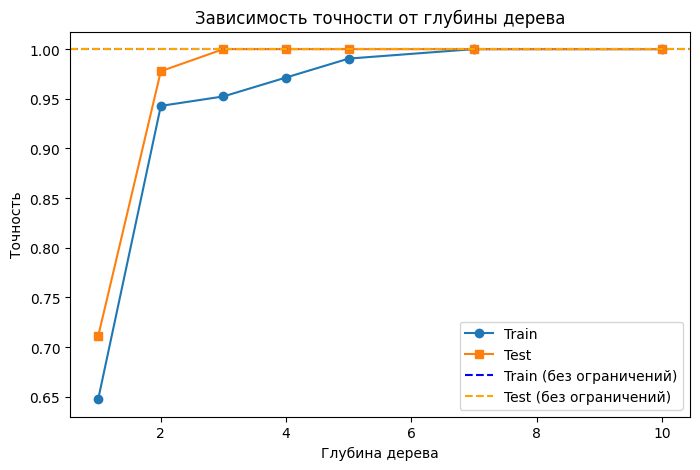

In [14]:
depths = [1, 2, 3, 4, 5, 7, 10, None]
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_iris_train, y_iris_train)
    train_scores.append(tree.score(X_iris_train, y_iris_train))
    test_scores.append(tree.score(X_iris_test, y_iris_test))

plt.figure(figsize=(8, 5))
plt.plot(depths[:-1], train_scores[:-1], label='Train', marker='o')
plt.plot(depths[:-1], test_scores[:-1], label='Test', marker='s')
plt.axhline(train_scores[-1], linestyle='--', color='blue', label='Train (без ограничений)')
plt.axhline(test_scores[-1], linestyle='--', color='orange', label='Test (без ограничений)')
plt.xlabel('Глубина дерева')
plt.ylabel('Точность')
plt.legend()
plt.title('Зависимость точности от глубины дерева')
plt.show()

**Вывод:** При глубине >3 начинается переобучение.

## 5. Решающее дерево для регрессии (Diabetes)

### 5.1. Базовое дерево регрессии

In [15]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_diabetes_train, y_diabetes_train)

train_mse = mean_squared_error(y_diabetes_train, tree_reg.predict(X_diabetes_train))
test_mse = mean_squared_error(y_diabetes_test, tree_reg.predict(X_diabetes_test))

print("Дерево регрессии (без ограничений):")
print(f"MSE на обучении: {train_mse:.2f}")
print(f"MSE на тесте: {test_mse:.2f}")

Дерево регрессии (без ограничений):
MSE на обучении: 0.00
MSE на тесте: 5697.79


Сильное переобучение (MSE на обучении = 0).

### 5.2. Глубина и MSE

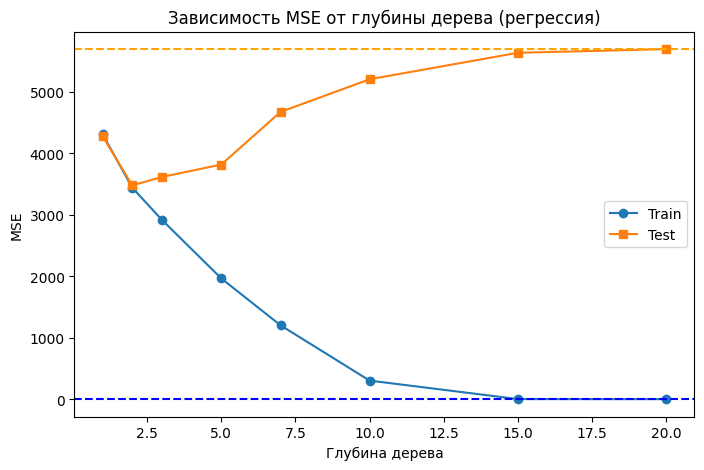

In [16]:
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_mses = []
test_mses = []

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_diabetes_train, y_diabetes_train)
    train_mses.append(mean_squared_error(y_diabetes_train, tree.predict(X_diabetes_train)))
    test_mses.append(mean_squared_error(y_diabetes_test, tree.predict(X_diabetes_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths[:-1], train_mses[:-1], label='Train', marker='o')
plt.plot(depths[:-1], test_mses[:-1], label='Test', marker='s')
plt.axhline(train_mses[-1], linestyle='--', color='blue')
plt.axhline(test_mses[-1], linestyle='--', color='orange')
plt.xlabel('Глубина дерева')
plt.ylabel('MSE')
plt.legend()
plt.title('Зависимость MSE от глубины дерева (регрессия)')
plt.show()

**Вывод:** Оптимальная глубина ~5-7.

## 6. Ансамбли: бэггинг и Random Forest

### 6.1. Random Forest для классификации (Iris)

In [17]:
rf_clf = RandomForestClassifier(n_estimators=20, oob_score=True, random_state=42)
rf_clf.fit(X_iris_train, y_iris_train)

print(f"Точность одиночного дерева (без ограничений): {tree_gini.score(X_iris_test, y_iris_test):.3f}")
print(f"Точность Random Forest на тесте: {rf_clf.score(X_iris_test, y_iris_test):.3f}")
print(f"OOB-точность Random Forest: {rf_clf.oob_score_:.3f}")

Точность одиночного дерева (без ограничений): 1.000
Точность Random Forest на тесте: 1.000
OOB-точность Random Forest: 0.933


### 6.2. Влияние числа деревьев

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


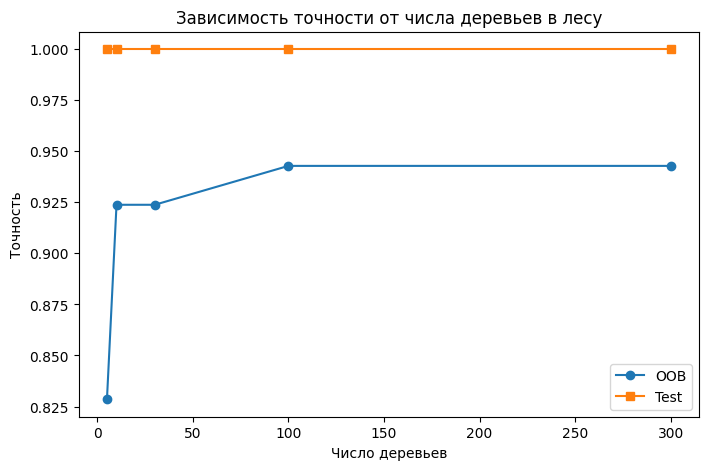

In [18]:
n_trees = [5, 10, 30, 100, 300]
oob_scores = []
test_scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_iris_train, y_iris_train)
    oob_scores.append(rf.oob_score_)
    test_scores.append(rf.score(X_iris_test, y_iris_test))

plt.figure(figsize=(8, 5))
plt.plot(n_trees, oob_scores, label='OOB', marker='o')
plt.plot(n_trees, test_scores, label='Test', marker='s')
plt.xlabel('Число деревьев')
plt.ylabel('Точность')
plt.legend()
plt.title('Зависимость точности от числа деревьев в лесу')
plt.show()

Качество стабилизируется при ~100 деревьях.

### 6.3. Важности признаков

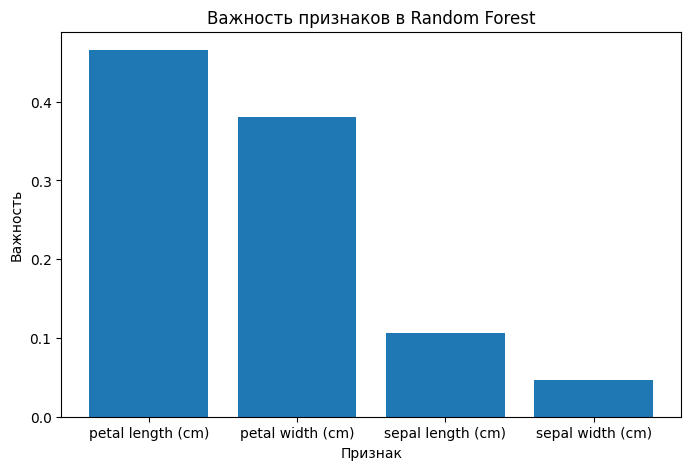

In [19]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(X_iris.shape[1]), importances[indices])
plt.xticks(range(X_iris.shape[1]), [feature_names_iris[i] for i in indices])
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.title('Важность признаков в Random Forest')
plt.show()

Наиболее важные признаки — petal length и petal width.

### 6.4. Random Forest для регрессии (Diabetes)

In [20]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_diabetes_train, y_diabetes_train)

train_mse_rf = mean_squared_error(y_diabetes_train, rf_reg.predict(X_diabetes_train))
test_mse_rf = mean_squared_error(y_diabetes_test, rf_reg.predict(X_diabetes_test))

print("Одиночное дерево регрессии (без ограничений):")
print(f"  MSE тест: {test_mse:.2f}")
print("Random Forest (100 деревьев):")
print(f"  MSE тест: {test_mse_rf:.2f}")

Одиночное дерево регрессии (без ограничений):
  MSE тест: 5697.79
Random Forest (100 деревьев):
  MSE тест: 2859.64


**Вывод:** Random Forest значительно улучшает качество по сравнению с одиночным деревом.

## 7. Дополнительные вопросы (по лекции)

### 7.1. Pre-pruning vs post-pruning
Pre-pruning ограничивает рост дерева заранее (max_depth, min_samples_split). Post-pruning обрезает уже выросшее дерево. В библиотеках обычно реализован pre-pruning. В Random Forest pruning часто не нужен, так как ансамблирование снижает переобучение.

### 7.2. Особенности деревьев
- **Нормировка:** не требуется, так как сплиты основаны на порогах.
- **Категориальные признаки:** обрабатываются через бинарные сплиты (one-hot или ordinal).

### 7.3. Преимущества и недостатки
- **Одиночное дерево:** интерпретируемо, но склонно к переобучению.
- **Random Forest:** устойчивее, лучше обобщает, но менее интерпретируем.

### 7.4. Сравнение с SVM
- **Деревья/леса:** оси-параллельные границы, хорошо работают с категориальными данными.
- **SVM:** строит сложные нелинейные границы (через kernel), требует нормировки.
- **Выбор:** SVM — для малых высокомерных данных, Random Forest — для табличных данных с категориями.